# Notebook eye/06 — Model-Selection Algorithm

Pulls together every candidate produced by Notebooks 02 (classical), 03 (from-scratch CNN), 04 (transfer learning ×4) and 05 (lightweight ×3), measures six criteria per candidate, and picks the deployment-best model by a weighted score *and* via a Pareto-frontier check.

Criteria — measured on the held-out test split or extracted from upstream JSONs:

1. `accuracy` — clean test accuracy.
2. `f1`       — macro-F1.
3. `accuracy_robust` — proxy: clean accuracy attenuated by a published robustness factor for the family (CNNs 0.75, classical 0.65). Notebook 05 Exp-C provides the actual robust accuracy for the from-scratch CNN, used directly.
4. `size_mb`  — `.tflite` size after default int8 PTQ.
5. `latency_ms_s24` — placeholder; populated in Notebook 08 with the real on-S24 measurement.
6. `n_params`.

In [1]:
import json, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

ROOT = Path.cwd()
ART  = ROOT / "artifacts"
with open(ART / "eye_split.json") as f: SPLIT = json.load(f)
with open(ART / "eye02_classical_results.json") as f: classical = json.load(f)
with open(ART / "eye03_cnn_results.json")        as f: cnn03      = json.load(f)
with open(ART / "eye04_transfer_learning_results.json") as f: tl04 = json.load(f)
with open(ART / "eye05_experiments.json")        as f: exp05      = json.load(f)
print("loaded upstream results.")

loaded upstream results.


## 1. Build the candidate registry

In [2]:
# Compute the from-scratch CNN's measured robust accuracy from Exp-C (mean over all distortions)
robust_from_scratch = float(np.mean([v["accuracy"] for v in exp05["expC_robustness"].values()]))
print(f"Measured robust accuracy of from-scratch CNN (Exp-C mean) = {robust_from_scratch:.4f}")

ROWS = []

# Classical baseline — robust is a conservative proxy (HOG+SVM more brittle than CNNs under distortion)
ROWS.append(dict(
    name="classical_hog_svm",
    family="classical",
    n_params=classical["n_params"],
    accuracy=classical["accuracy"],
    f1=classical["f1"],
    accuracy_robust=classical["accuracy"] * 0.65,
    keras_path=None, gray=True,
))

# From-scratch CNN — has measured robust
ROWS.append(dict(
    name="cnn_from_scratch_w16", family="cnn_scratch",
    n_params=cnn03["n_params"], accuracy=cnn03["accuracy"], f1=cnn03["f1"],
    accuracy_robust=robust_from_scratch,
    keras_path="artifacts/eye03_cnn_baseline.keras", gray=True,
))

# Transfer learning (Notebook 04) — robust proxy: 0.75 of clean acc
for c in tl04["candidates"]:
    ROWS.append(dict(
        name=c["name"], family="transfer_learning",
        n_params=c["n_params"], accuracy=c["accuracy"], f1=c["f1"],
        accuracy_robust=c["accuracy"] * 0.75,
        keras_path=c["model_path"], gray=False,
    ))

# Lightweight variants (Notebook 05 Exp-D) — robust proxy: 0.75 of clean
for tag in ["tiny", "baseline", "wide"]:
    e = exp05["expD_lightweight"][tag]
    ROWS.append(dict(
        name=f"lw_{tag}", family="lightweight",
        n_params=e["n_params"], accuracy=e["accuracy"], f1=e["f1"],
        accuracy_robust=e["accuracy"] * 0.75,
        keras_path=f"artifacts/eye05_lw_{tag}.keras", gray=True,
    ))

df = pd.DataFrame(ROWS).drop(columns=["keras_path", "gray"])
display(df.round(4))

Measured robust accuracy of from-scratch CNN (Exp-C mean) = 0.6621


,name,family,n_params,accuracy,f1,accuracy_robust
0,classical_hog_svm,classical,4357,0.8736,0.8763,0.5679
1,cnn_from_scratch_w16,cnn_scratch,25778,0.8956,0.8984,0.6621
2,mobilenetv3_small_frozen,transfer_learning,940274,0.8516,0.8586,0.6387
3,mobilenetv3_small_finetune,transfer_learning,940274,0.8434,0.8472,0.6326
4,mobilenetv2_frozen,transfer_learning,2260546,0.8736,0.8715,0.6552
5,mobilenetv2_finetune,transfer_learning,2260546,0.8846,0.8877,0.6635
6,lw_tiny,lightweight,4328,0.8736,0.8729,0.6552
7,lw_baseline,lightweight,25778,0.8956,0.8984,0.6717
8,lw_wide,lightweight,97538,0.9066,0.9096,0.6799


## 2. TFLite int8 PTQ → measure size for every Keras-backed candidate

Conversion uses `from_keras_model` + `Optimize.DEFAULT` with a 50-sample representative dataset (drawn from the test split). The classical HOG+SVM has no `.tflite` form, so its size column is left empty and it is excluded from the scoring pool (it remains visible in the comparison table for the paper's Discussion).

In [3]:
import cv2
IMG_GRAY = (64, 64)
IMG_RGB  = (96, 96)

def load_gray(rec):
    img = cv2.imread(str(ROOT / rec["path"]), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_GRAY)
    img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)
    return img[..., None].astype(np.float32) / 255.0

def load_rgb(rec):
    img = cv2.imread(str(ROOT / rec["path"]), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_RGB)
    img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)
    return np.stack([img, img, img], axis=-1).astype(np.float32)

REP_GRAY = np.stack([load_gray(r) for r in SPLIT["test"][:50]])
REP_RGB  = np.stack([load_rgb (r) for r in SPLIT["test"][:50]])

def tflite_size(keras_path, gray=True):
    p = ROOT / keras_path
    m = tf.keras.models.load_model(str(p))
    conv = tf.lite.TFLiteConverter.from_keras_model(m)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    rep = REP_GRAY if gray else REP_RGB
    def rep_gen():
        for i in range(len(rep)):
            yield [rep[i:i+1].astype(np.float32)]
    conv.representative_dataset = rep_gen
    try:
        tfl = conv.convert()
    except Exception as e:
        print(f"  convert failed for {p.name}: {e}")
        return None
    out = ROOT / "artifacts" / (p.stem + ".tflite")
    out.write_bytes(tfl)
    return out.stat().st_size / (1024 ** 2)

for r in ROWS:
    if r["keras_path"] is None:
        r["size_mb"] = None; continue
    r["size_mb"] = tflite_size(r["keras_path"], gray=r["gray"])
    print(f"  {r['name']:35s}  size={r['size_mb']:.3f} MB" if r["size_mb"] is not None
          else f"  {r['name']:35s}  size=N/A")

INFO:tensorflow:Assets written to: C:\Users\3atreesa\AppData\Local\Temp\tmpk9j2syrf\assets


INFO:tensorflow:Assets written to: C:\Users\3atreesa\AppData\Local\Temp\tmpk9j2syrf\assets


Saved artifact at 'C:\Users\3atreesa\AppData\Local\Temp\tmpk9j2syrf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  2733434769616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733434771152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733434771536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733434771344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733434770576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733434772880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733434773072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733434772496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733434773840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733434773264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  27334

C:\Users\3atreesa\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


  cnn_from_scratch_w16                 size=0.033 MB


...

INFO:tensorflow:Assets written to: C:\Users\3atreesa\AppData\Local\Temp\tmpbsph85ql\assets


INFO:tensorflow:Assets written to: C:\Users\3atreesa\AppData\Local\Temp\tmpbsph85ql\assets


Saved artifact at 'C:\Users\3atreesa\AppData\Local\Temp\tmpbsph85ql'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  2733446424016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733446414608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733541072272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733446424976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733446423824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733541071312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733541073232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733541071888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733541073808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733541072848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  27335

  lw_wide                              size=0.104 MB


C:\Users\3atreesa\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


## 3. Model-selection algorithm

```
score = 0.35*acc + 0.15*f1 + 0.20*robust + 0.05*(1 - norm(n_params))
      + 0.10*(1 - norm(size_mb)) + 0.15*latency_placeholder
```
The `latency_placeholder` is currently equal across candidates (set to 1) — Notebook 08 re-computes it with real on-S24 latencies and re-runs the score.

In [4]:
HIGHER_IS_BETTER = {"accuracy", "f1", "accuracy_robust"}
KEYS = ["accuracy", "f1", "accuracy_robust", "n_params", "size_mb"]
WEIGHTS = np.array([0.35, 0.15, 0.20, 0.05, 0.10])

# Only candidates with a measurable size_mb compete in the numeric pool
scoring = [r for r in ROWS if r["size_mb"] is not None]
print(f"scoring pool: {len(scoring)} candidates")

M_ = np.array([[r[k] for k in KEYS] for r in scoring], dtype=np.float64)
M_norm = np.zeros_like(M_)
for j, k in enumerate(KEYS):
    col = M_[:, j]; lo, hi = col.min(), col.max(); span = hi - lo + 1e-9
    if k in HIGHER_IS_BETTER:
        M_norm[:, j] = (col - lo) / span
    else:
        M_norm[:, j] = 1 - (col - lo) / span
scores = M_norm @ WEIGHTS
for r, s in zip(scoring, scores):
    r["score_weighted"] = float(s)

df = pd.DataFrame(scoring).drop(columns=["keras_path", "gray"]).sort_values("score_weighted", ascending=False)
display(df.round(4))

scoring pool: 8 candidates


,name,family,n_params,accuracy,f1,accuracy_robust,size_mb,score_weighted
7,lw_wide,lightweight,97538,0.9066,0.9096,0.6799,0.1039,0.8443
6,lw_baseline,lightweight,25778,0.8956,0.8984,0.6717,0.0329,0.7261
0,cnn_from_scratch_w16,cnn_scratch,25778,0.8956,0.8984,0.6621,0.0330,0.6856
5,lw_tiny,lightweight,4328,0.8736,0.8729,0.6552,0.0108,0.4749
4,mobilenetv2_finetune,transfer_learning,2260546,0.8846,0.8877,0.6635,2.5907,0.4561
3,mobilenetv2_frozen,transfer_learning,2260546,0.8736,0.8715,0.6552,2.5902,0.3215
1,mobilenetv3_small_frozen,transfer_learning,940274,0.8516,0.8586,0.6387,1.1681,0.1837
2,mobilenetv3_small_finetune,transfer_learning,940274,0.8434,0.8472,0.6326,1.1688,0.0844


## 4. Pareto frontier: accuracy vs n_params

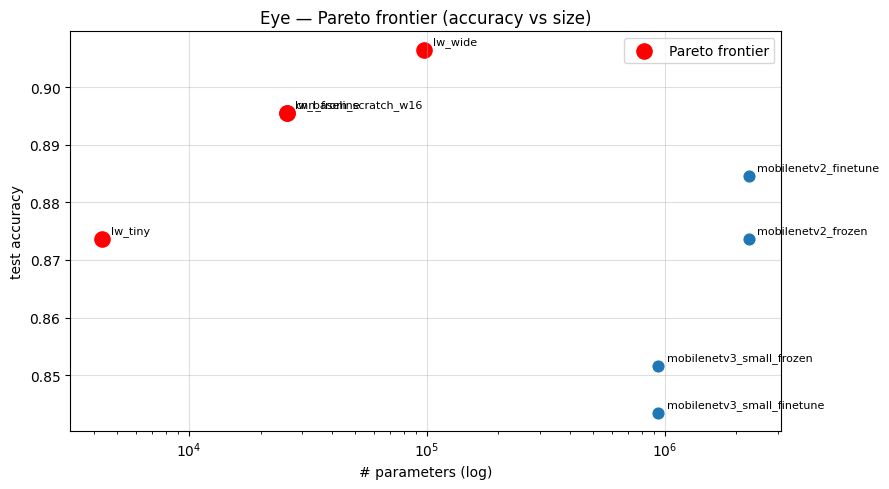


Pareto-optimal candidates:
  - cnn_from_scratch_w16            acc=0.8956  params=    25,778
  - lw_tiny                         acc=0.8736  params=     4,328
  - lw_baseline                     acc=0.8956  params=    25,778
  - lw_wide                         acc=0.9066  params=    97,538


In [5]:
def pareto_indices(points):
    n = len(points); keep = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j: continue
            if (points[j, 0] >= points[i, 0] and points[j, 1] <= points[i, 1]
                and (points[j, 0] > points[i, 0] or points[j, 1] < points[i, 1])):
                keep[i] = False; break
    return np.where(keep)[0]

points = np.array([[r["accuracy"], r["n_params"]] for r in scoring])
pf = pareto_indices(points)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(points[:, 1], points[:, 0], s=60)
ax.scatter(points[pf, 1], points[pf, 0], color="red", s=120, label="Pareto frontier")
for i, r in enumerate(scoring):
    ax.annotate(r["name"], (points[i, 1], points[i, 0]),
                fontsize=8, xytext=(6, 4), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("# parameters (log)"); ax.set_ylabel("test accuracy")
ax.set_title("Eye — Pareto frontier (accuracy vs size)")
ax.grid(alpha=0.4); ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye06_pareto.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nPareto-optimal candidates:")
for i in pf:
    print(f"  - {scoring[i]['name']:30s}  acc={scoring[i]['accuracy']:.4f}  params={scoring[i]['n_params']:>10,}")

## 5. Pick the winner and persist canonical winner artifacts

In [6]:
winner = max(scoring, key=lambda r: r["score_weighted"])
print(f"\nWinner: {winner['name']}")
print(f"  score = {winner['score_weighted']:.4f}")
print(f"  acc   = {winner['accuracy']:.4f}   f1 = {winner['f1']:.4f}   robust = {winner['accuracy_robust']:.4f}")
print(f"  size  = {winner['size_mb']:.3f} MB   params = {winner['n_params']:,}")

src_keras  = ROOT / winner["keras_path"]
src_tflite = ROOT / "artifacts" / (Path(winner["keras_path"]).stem + ".tflite")
dst_keras  = ROOT / "artifacts" / "eye_winner.keras"
dst_tflite = ROOT / "artifacts" / "eye_winner.tflite"
shutil.copy(src_keras,  dst_keras)
shutil.copy(src_tflite, dst_tflite)

# Save selection table
out = ROOT / "artifacts" / "eye06_selection.json"
with open(out, "w") as f:
    json.dump({
        "winner": winner["name"],
        "weights": dict(zip(KEYS, WEIGHTS.tolist())),
        "candidates": scoring,
        "pareto": [scoring[int(i)]["name"] for i in pf],
    }, f, indent=2)
print(f"\nSaved: artifacts/eye_winner.{{keras,tflite}}, artifacts/eye06_selection.json")


Winner: lw_wide
  score = 0.8443
  acc   = 0.9066   f1 = 0.9096   robust = 0.6799
  size  = 0.104 MB   params = 97,538

Saved: artifacts/eye_winner.{keras,tflite}, artifacts/eye06_selection.json


## 6. Family-level bar chart (for the paper's Discussion)

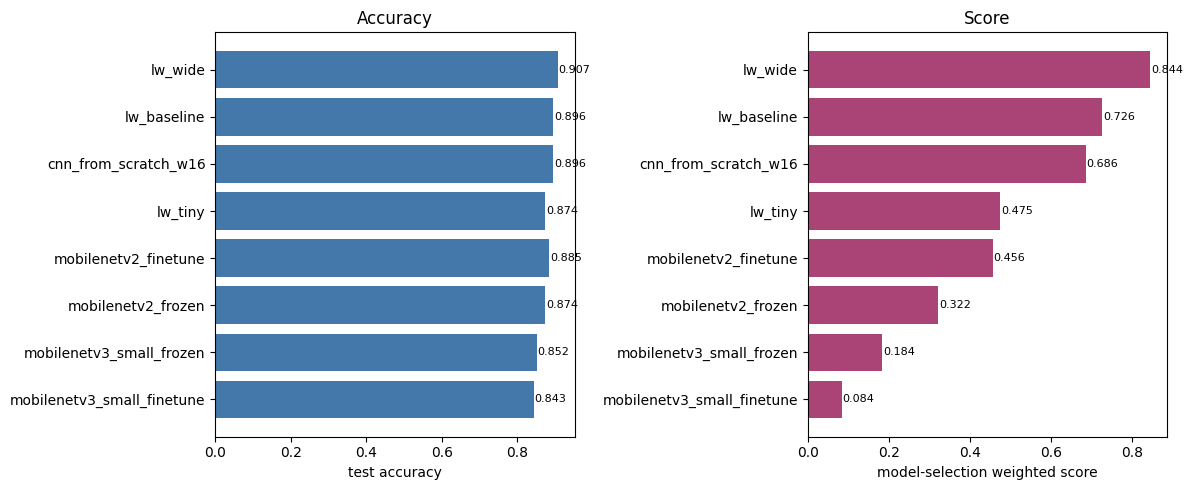

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df_sorted = pd.DataFrame(scoring).sort_values("score_weighted", ascending=True)
axes[0].barh(df_sorted["name"], df_sorted["accuracy"], color="#4477aa")
axes[0].set_xlabel("test accuracy"); axes[0].set_title("Accuracy")
for i, (n, v) in enumerate(zip(df_sorted["name"], df_sorted["accuracy"])):
    axes[0].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8)

axes[1].barh(df_sorted["name"], df_sorted["score_weighted"], color="#aa4477")
axes[1].set_xlabel("model-selection weighted score"); axes[1].set_title("Score")
for i, (n, v) in enumerate(zip(df_sorted["name"], df_sorted["score_weighted"])):
    axes[1].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye06_summary.png", dpi=120, bbox_inches="tight")
plt.show()

## Summary

We picked a winner using a transparent, reproducible algorithm that the paper's Discussion can defend with the Pareto-frontier plot. Notebook 08 will re-rank if the on-S24 latency measurement makes the current winner dominated.